In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Dataset size
N = 3000

# Generate inputs
x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

X = np.column_stack((x1, x2))

# Target rule: nonlinear boundary
y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1, 1)

# Binary classification problem

In [3]:
# Shuffle indices
indices = np.random.permutation(N)

train_end = int(0.7 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_slope(z):
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    return np.maximum(0, z)

def relu_slope(z):
    return (z > 0).astype(float)

In [5]:
def bce_loss(y_hat, y):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))

def bce_grad(y_hat, y):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return (y_hat - y) / len(y)

In [6]:
def init_network(layer_sizes):
    
    weights = []
    biases = []
    
    for i in range(len(layer_sizes) - 1):
        W = np.random.uniform(-1, 1, (layer_sizes[i], layer_sizes[i+1]))
        b = np.zeros((1, layer_sizes[i+1]))
        
        weights.append(W)
        biases.append(b)
        
    return weights, biases

In [7]:
def forward_pass(X, weights, biases, activation_fn):
    
    activations = [X]
    z_values = []
    
    A = X
    
    for i in range(len(weights) - 1):
        Z = A @ weights[i] + biases[i]
        A = activation_fn(Z)
        
        z_values.append(Z)
        activations.append(A)
    
    # Output layer (sigmoid)
    Z_out = A @ weights[-1] + biases[-1]
    y_hat = sigmoid(Z_out)
    
    z_values.append(Z_out)
    activations.append(y_hat)
    
    return activations, z_values

In [8]:
def backward_pass(y, activations, z_values, weights, activation_slope_fn):
    
    grads_W = []
    grads_b = []
    
    # Output layer gradient
    dL_dy = bce_grad(activations[-1], y)
    dZ = dL_dy
    
    # Loop backward
    for i in reversed(range(len(weights))):
        
        A_prev = activations[i]
        
        dW = A_prev.T @ dZ
        db = np.sum(dZ, axis=0, keepdims=True)
        
        grads_W.insert(0, dW)
        grads_b.insert(0, db)
        
        if i > 0:
            dA = dZ @ weights[i].T
            dZ = dA * activation_slope_fn(z_values[i-1])
    
    return grads_W, grads_b

In [9]:
def accuracy(y_hat, y):
    preds = (y_hat >= 0.5).astype(int)
    return np.mean(preds == y)

In [10]:
def grad_norm(grads_W):
    total = 0
    for g in grads_W:
        total += np.sum(g**2)
    return np.sqrt(total)

In [11]:
def sgd_update(weights, biases, grads_W, grads_b, lr):
    
    for i in range(len(weights)):
        weights[i] -= lr * grads_W[i]
        biases[i] -= lr * grads_b[i]
        
    return weights, biases

In [12]:
def momentum_update(weights, biases, grads_W, grads_b,
                    vW, vB, lr, beta=0.9):
    
    for i in range(len(weights)):
        vW[i] = beta * vW[i] + lr * grads_W[i]
        vB[i] = beta * vB[i] + lr * grads_b[i]
        
        weights[i] -= vW[i]
        biases[i] -= vB[i]
        
    return weights, biases, vW, vB

In [13]:
def train_model(layer_sizes, activation_name="relu",
                optimizer="sgd", epochs=200, lr=0.01):
    
    if activation_name == "relu":
        act = relu
        act_slope = relu_slope
    else:
        act = sigmoid
        act_slope = sigmoid_slope
    
    weights, biases = init_network(layer_sizes)
    
    # Momentum buffers
    vW = [np.zeros_like(w) for w in weights]
    vB = [np.zeros_like(b) for b in biases]
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    for epoch in range(epochs):
        
        # Forward
        activations, z_vals = forward_pass(X_train, weights, biases, act)
        y_hat = activations[-1]
        
        loss = bce_loss(y_hat, y_train)
        
        # Backward
        grads_W, grads_b = backward_pass(
            y_train, activations, z_vals, weights, act_slope
        )
        
        # Update
        if optimizer == "sgd":
            weights, biases = sgd_update(weights, biases, grads_W, grads_b, lr)
        else:
            weights, biases, vW, vB = momentum_update(
                weights, biases, grads_W, grads_b,
                vW, vB, lr
            )
        
        # Metrics
        train_losses.append(loss)
        train_accs.append(accuracy(y_hat, y_train))
        
        # Validation
        val_acts, _ = forward_pass(X_val, weights, biases, act)
        val_yhat = val_acts[-1]
        
        val_losses.append(bce_loss(val_yhat, y_val))
        val_accs.append(accuracy(val_yhat, y_val))
    
    return weights, biases, train_losses, val_losses, train_accs, val_accs

In [14]:
# 2-layer network: input → 4 hidden → output
layers = [2, 4, 1]

weights, biases, train_losses, val_losses, train_accs, val_accs = train_model(
    layers,
    activation_name="relu",
    optimizer="sgd",
    epochs=300,
    lr=0.01
)

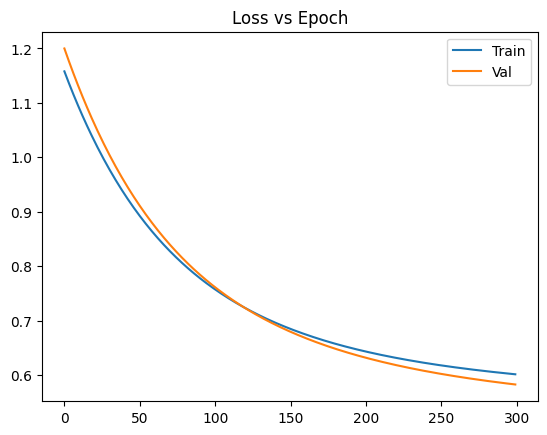

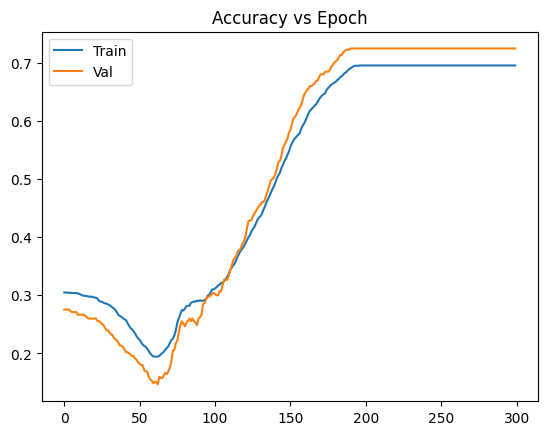

In [15]:
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.title("Loss vs Epoch")
plt.legend(["Train", "Val"])
plt.show()

plt.figure()
plt.plot(train_accs)
plt.plot(val_accs)
plt.title("Accuracy vs Epoch")
plt.legend(["Train", "Val"])
plt.show()